In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from practice.data_analysis_practice import avg_song_len
from src.cleaning import song_lyrics

In [2]:
# Song dataframe
df = pd.read_csv("../data/processed/processed_song_data.csv")
df.head()

,album,song,lyrics
0,1989 (TV),AllYouHadToDoWasStay_TaylorsVersion_,"(Hey, hey, hey) (Hey, hey, hey) (Hey, hey, hey..."
1,1989 (TV),BadBlood_TaylorsVersion_,"'Cause, baby, now we got bad blood You know it..."
2,1989 (TV),BlankSpace_TaylorsVersion_,"Nice to meet you, where you been? I could show..."
3,1989 (TV),Clean_TaylorsVersion_,"The drought was the very worst, ah-ah, ah-ah W..."
4,1989 (TV),HowYouGetTheGirl_TaylorsVersion_,"Oh, oh, oh Oh, oh, oh Oh, oh Oh, oh Stand ther..."


In [3]:
release_order = {
    'TaylorSwift': 1,
    'Fearless (TV)': 2,
    'Speak Now (TV)': 3,
    'Red (TV)': 4,
    '1989 (TV)': 5,
    'Reputation': 6,
    'Lover': 7,
    'Folklore': 8,
    'Evermore': 9,
    'Midnights': 10,
    'TTPD': 11
}

In [4]:
df['release_order'] = df['album'].map(release_order)

df.sort_values('release_order', inplace=True, ignore_index=True)
df

,album,song,lyrics,release_order
0,TaylorSwift,ColdasYou,You have a way of coming easily to me And when...,1
1,TaylorSwift,APerfectlyGoodHeart,Why would you wanna break A perfectly good hea...,1
2,TaylorSwift,TimMcGraw,He said the way my blue eyes shined Put those ...,1
3,TaylorSwift,TiedTogetherwithaSmile,Seems the only one who doesn't see your beauty...,1
4,TaylorSwift,TheOutside,I didn't know what I would find When I went lo...,1
...,...,...,...,...
221,TTPD,TheManuscript,"Now and then, she rereads the manuscript Of th...",11
222,TTPD,TheProphecy,"One, two, three, four Hand on the throttle Tho...",11
223,TTPD,TheSmallestManWhoEverLived,Was any of it true? Gazing at me starry-eyed I...,11
224,TTPD,TheTorturedPoetsDepartment,You left your typewriter at my apartment Strai...,11


In [5]:
# Album dataframe
album_df = pd.DataFrame({'album_title': df['album'].unique()})
album_df

,album_title
0,TaylorSwift
1,Fearless (TV)
2,Speak Now (TV)
3,Red (TV)
4,1989 (TV)
5,Reputation
6,Lover
7,Folklore
8,Evermore
9,Midnights


## Length of each album
How many songs in each album

In [9]:
counts = df.groupby('album', sort=False)['song'].count()

album_df['no. of songs'] = album_df['album_title'].map(counts)
album_df

,album_title,no. of songs
0,TaylorSwift,14
1,Fearless (TV),25
2,Speak Now (TV),22
3,Red (TV),28
4,1989 (TV),21
5,Reputation,15
6,Lover,18
7,Folklore,16
8,Evermore,15
9,Midnights,21


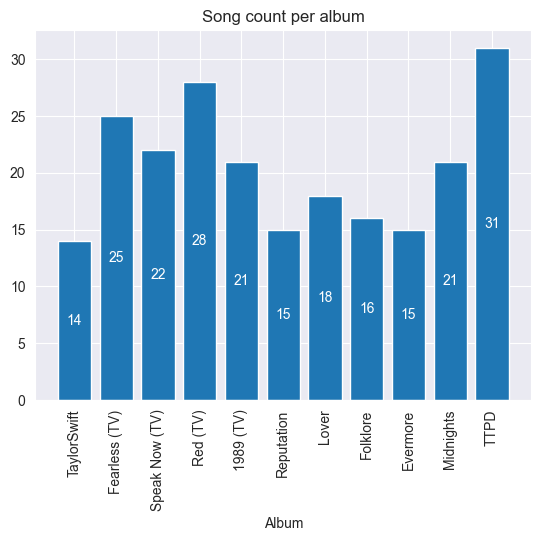

In [10]:
bars = plt.bar(counts.index, counts)
plt.xticks(rotation=90)

plt.bar_label(bars, label_type='center', color = 'white')

plt.xlabel('Album')
plt.title('Song count per album')

plt.show()

## Song length in words
And the average song length per album

In [14]:
song_lyrics = df.iloc[0]['lyrics']
len(song_lyrics.split(' '))

249

In [16]:
df['song_length_in_words'] = df['lyrics'].apply(lambda x: len(x.split(' ')))
df.head()

,album,song,lyrics,release_order,song_length_in_words
0,TaylorSwift,ColdasYou,You have a way of coming easily to me And when...,1,249
1,TaylorSwift,APerfectlyGoodHeart,Why would you wanna break A perfectly good hea...,1,232
2,TaylorSwift,TimMcGraw,He said the way my blue eyes shined Put those ...,1,366
3,TaylorSwift,TiedTogetherwithaSmile,Seems the only one who doesn't see your beauty...,1,254
4,TaylorSwift,TheOutside,I didn't know what I would find When I went lo...,1,234


In [21]:
avg_song_len = df.groupby('album')['song_length_in_words'].mean()

album_df['avg_song_length'] = album_df['album_title'].map(avg_song_len)
album_df['avg_song_length'] = album_df['avg_song_length'].round().astype(int)
album_df

,album_title,no. of songs,avg_song_length
0,TaylorSwift,14,287
1,Fearless (TV),25,336
2,Speak Now (TV),22,400
3,Red (TV),28,376
4,1989 (TV),21,426
5,Reputation,15,480
6,Lover,18,375
7,Folklore,16,306
8,Evermore,15,347
9,Midnights,21,336


## Tokenization, Stop word Removal and Lemmatization


In [22]:
from src.nlp_analysis import join_lyrics, tokenize, stop_word_rem, top_nouns, get_sentiment

In [26]:
# Tokenization
album_lyrics = df.groupby('album')['lyrics'].apply(tokenize)

album_df['album_lyrics'] = album_df['album_title'].map(album_lyrics)
# album_df

In [27]:
# Stop word Removal
album_df['filtered_lyrics'] = album_df['album_lyrics'].apply(stop_word_rem)
# album_df


In [28]:
# Lemmatization
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [29]:
# loops through each album, then loops through each word in album to lemmatize it
album_df['lemmatized_lyrics'] = album_df['filtered_lyrics'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
album_df

,album_title,no. of songs,avg_song_length,album_lyrics,filtered_lyrics,lemmatized_lyrics
0,TaylorSwift,14,287,"[you, have, a, way, of, coming, easily, to, me...","[coming, easily, take, take, best, start, figh...","[coming, easily, take, take, best, start, figh..."
1,Fearless (TV),25,336,"[this, is, wrong, but, i, ca, n't, help, but, ...","[wrong, help, feel, right, babe, misty, mornin...","[wrong, help, feel, right, babe, misty, mornin..."
2,Speak Now (TV),22,400,"[tall, ,, dark, ,, and, superman, he, puts, pa...","[tall, dark, superman, puts, papers, briefcase...","[tall, dark, superman, put, paper, briefcase, ..."
3,Red (TV),28,376,"[i, walked, through, the, door, with, you, ,, ...","[walked, door, air, cold, somethin, felt, home...","[walked, door, air, cold, somethin, felt, home..."
4,1989 (TV),21,426,"[he, said, ,, ``, let, 's, get, out, of, this,...","[said, let, town, drive, city, away, crowds, t...","[said, let, town, drive, city, away, crowd, th..."
5,Reputation,15,480,"[knew, he, was, a, killer, first, time, that, ...","[knew, killer, first, saw, wondered, many, gir...","[knew, killer, first, saw, wondered, many, gir..."
6,Lover,18,375,"[combat, ,, i, 'm, ready, for, combat, i, say,...","[combat, ready, combat, say, want, cruelty, wi...","[combat, ready, combat, say, want, cruelty, wi..."
7,Folklore,16,306,"[we, gather, here, ,, we, line, up, ,, weepin,...","[gather, line, weepin, sunlit, room, fire, mad...","[gather, line, weepin, sunlit, room, fire, mad..."
8,Evermore,15,347,"[fatefully, i, tried, to, pick, my, battles, '...","[fatefully, tried, pick, battles, battle, pick...","[fatefully, tried, pick, battle, battle, picke..."
9,Midnights,21,336,"[lock, broken, ,, slur, spoken, wound, open, ,...","[lock, broken, slur, spoken, wound, open, game...","[lock, broken, slur, spoken, wound, open, game..."


## Most common words - this is just a frequency based statistic
and most common nouns

In [30]:
from collections import Counter

In [31]:
# Top 10 words - from all words
album_df['top10_words'] = album_df['lemmatized_lyrics'].apply(lambda words: Counter(words).most_common(10))
album_df[['album_title', 'top10_words']]


,album_title,top10_words
0,TaylorSwift,"[(think, 26), (never, 25), (back, 25), (would,..."
1,Fearless (TV),"[(come, 58), (baby, 46), (say, 42), (never, 41..."
2,Speak Now (TV),"[(never, 53), (love, 49), (would, 45), (back, ..."
3,Red (TV),"[(never, 70), (back, 59), (run, 58), (love, 54..."
4,1989 (TV),"[(love, 111), (wish, 81), (say, 74), (shake, 7..."
5,Reputation,"[(made, 53), (want, 51), (call, 47), (baby, 39..."
6,Lover,"[(want, 52), (love, 44), (never, 43), (dayligh..."
7,Folklore,"[(never, 46), (would, 31), (think, 21), (gave,..."
8,Evermore,"[(could, 31), (think, 27), (never, 20), (love,..."
9,Midnights,"[(love, 38), (never, 34), (karma, 28), (around..."


In [32]:
# Top 10 Nouns
album_df['top_nouns'] = album_df['lemmatized_lyrics'].apply(top_nouns)
album_df[['album_title', 'top_nouns']]

,album_title,top_nouns
0,TaylorSwift,"[(song, 15), (baby, 14), (everything, 12), (ey..."
1,Fearless (TV),"[(baby, 41), (everything, 26), (rain, 24), (ni..."
2,Speak Now (TV),"[(life, 26), (mind, 23), (day, 21), (eye, 17),..."
3,Red (TV),"[(night, 47), (trouble, 33), (eye, 26), (love,..."
4,1989 (TV),"[(love, 81), (baby, 47), (wood, 38), (york, 30..."
5,Reputation,"[(call, 45), (baby, 33), (game, 32), (hand, 27..."
6,Lover,"[(man, 37), (daylight, 34), (baby, 27), (stree..."
7,Folklore,"[(sign, 14), (woman, 13), (everything, 11), (h..."
8,Evermore,"[(man, 15), (eye, 13), (hand, 13), (day, 11), ..."
9,Midnights,"[(love, 17), (night, 16), (someone, 15), (beac..."
